<a href="https://colab.research.google.com/github/JoshuaCora1806/mi-lab15-vectorial-cs/blob/develop/MD_lab15_vectorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

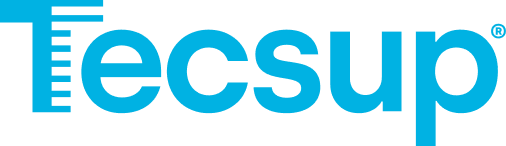

**DEPARTAMENTO DE TECNOLOGÍA DIGITAL Y GESTIÓN**

**Carrera de Big Data y Ciencia de Datos**

# Laboratorio 15 - Bases de datos vectoriales

**Integrantes**
- Cora Salazar, Joshua Jian
- Olortegui Perez, Kevin Estiben

In [ ]:
!pip install chromadb sentence-transformers

In [ ]:
import chromadb
from sentence_transformers import SentenceTransformer

In [ ]:
# Inicializar el motor de vectores local
client = chromadb.Client()

# Crear coleción (equivalente a una tabla)
collection = client.create_collection(name="alumnos")
model = SentenceTransformer('all-MiniLM-L6-v2') # Modelo de embedding

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# Lista de documentos de ejemplos
docs = [
    'Luis es un excelente alumno de ciencia de datos',
    'María tiene interés en la inteligencia artificial',
    'Pedro trabaja en procesamiento de lenguaje natural'
]

# Generar vectores
embeddings = model.encode(docs).tolist()

# Insertar en la colección
collection.add(
    documents=docs,
    embeddings=embeddings,
    ids=['1','2','3']
)

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionAddEvent: capture() takes 1 positional argument but 3 were given


In [ ]:
query='¿Quién es el alumno sobresaliente?'
query_embedding = model.encode(query).tolist()

# Buscar los 2 más cercanos
results = collection.query(
    query_embeddings=query_embedding,
    n_results=2
)

print(results['documents'])

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


[['Pedro trabaja en procesamiento de lenguaje natural', 'Luis es un excelente alumno de ciencia de datos']]


In [ ]:
data = collection.get(include=['embeddings','documents'])

for doc, id_, emb in zip(data['documents'], data['ids'], data['embeddings']):
    print(f'ID: {id_}')
    print(f'Documento: {doc}')
    print(f'Embedding (primeras 5 dimensiones): {emb[:5]}')
    print('-'*30)

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionGetEvent: capture() takes 1 positional argument but 3 were given


ID: 1
Documento: Luis es un excelente alumno de ciencia de datos
Embedding (primeras 5 dimensiones): [-0.0515781   0.07000642 -0.04834177 -0.05982044 -0.01550355]
------------------------------
ID: 2
Documento: María tiene interés en la inteligencia artificial
Embedding (primeras 5 dimensiones): [-0.03857211 -0.01005658  0.00841351 -0.03409148 -0.09196933]
------------------------------
ID: 3
Documento: Pedro trabaja en procesamiento de lenguaje natural
Embedding (primeras 5 dimensiones): [ 0.04198885  0.0491558  -0.02113147  0.01458174 -0.09477768]
------------------------------


In [ ]:
data = collection.get()
print(data)

{'ids': ['1', '2', '3'], 'embeddings': None, 'documents': ['Luis es un excelente alumno de ciencia de datos', 'María tiene interés en la inteligencia artificial', 'Pedro trabaja en procesamiento de lenguaje natural'], 'uris': None, 'included': ['metadatas', 'documents'], 'data': None, 'metadatas': [None, None, None]}


**Ahora que ya sabe lo básico, desarrolle lo siguiente:**

Cree una base de datos vectorial llamado “Tecsup” y guarde información personal suya y de sus compañeros y luego cree un prompt para poder capturar las respuestas en base a lo guardado.

Luego, utilice la misma solución pero con otro motor de embedding y compare sus respuestas.

In [ ]:
collection = client.create_collection(name="tecsup")
model = SentenceTransformer('all-mpnet-base-v2') # Modelo de embedding

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# Lista de documentos de ejemplo
docs = [
    'Joshua Jian Cora Salazar estudia la carrera de big data y ciencia de datos',
    'Joshua Jian Cora Salazar cursa el 5to ciclo',
    'Joshua Jian Cora Salazar es un estudiante de tipo regular'
    'Kevin Estiben Olortegui Perez estudia la carrera de big data y ciencia de datos',
    'Kevin Estiben Olortegui Perez cursa el 5to ciclo',
    'Kevin Estiben Olortegui Perez es un beneficiario de BECA 18',
    'Abraham Sebastián Jonathan Huamán Quispe estudia la carrera de big data y ciencia de datos',
    'Abraham Sebastián Jonathan Huamán Quispe cursa el 5to ciclo',
    'Abraham Sebastián Jonathan Huamán Quispe es un estudiante de tipo regular'
]